In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("data.csv")

In [26]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   total_stop_frames       584 non-null    int64  
 1   longest_stop_frames     584 non-null    int64  
 2   num_stop_events         584 non-null    int64  
 3   mean_stop_duration      584 non-null    float64
 4   mean_velocity           584 non-null    float64
 5   max_velocity            584 non-null    float64
 6   velocity_std            584 non-null    float64
 7   max_acceleration        584 non-null    float64
 8   max_deceleration        584 non-null    float64
 9   acceleration_std        584 non-null    float64
 10  position_std            584 non-null    float64
 11  frames_after_last_stop  584 non-null    int64  
 12  object_file             584 non-null    str    
 13  hard_stop               584 non-null    int64  
 14  momentary_stop          584 non-null    int64  
dtype

,total_stop_frames,longest_stop_frames,num_stop_events,mean_stop_duration,mean_velocity,max_velocity,velocity_std,max_acceleration,max_deceleration,acceleration_std,position_std,frames_after_last_stop,hard_stop,momentary_stop
count,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000
mean,632.426370,611.753425,4.347603,605.364659,16.687469,30.683034,5.652599,14.763041,-4.318743,1.111890,622.646294,298.325342,0.066781,0.378425
std,2248.161245,2252.039771,7.660063,2253.437483,10.561142,12.803760,2.975686,9.775175,4.540874,0.930048,396.007119,223.011527,0.249856,0.485410
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-32.165000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,1.000000,6.620456,22.703000,3.742152,9.103750,-5.238750,0.533359,298.611703,123.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,1.000000,17.196485,31.105000,5.436542,13.213500,-2.947500,0.869978,551.231351,276.500000,0.000000,0.000000
75%,40.250000,16.000000,3.000000,5.517857,25.297575,39.476500,7.396227,19.759250,-1.842750,1.453020,1040.802535,431.500000,0.000000,1.000000
max,9022.000000,9022.000000,68.000000,9022.000000,48.487771,79.183000,15.770169,53.495000,0.000000,5.575316,1519.414577,1953.000000,1.000000,1.000000


In [27]:
features = ["total_stop_frames", 
            "longest_stop_frames", 
            "num_stop_events", 
            "mean_stop_duration", 
            "mean_velocity", 
            "max_velocity", 
            "velocity_std", 
            "max_acceleration", 
            "max_deceleration", 
            "acceleration_std", 
            "position_std", 
            "frames_after_last_stop"
           ]


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [18]:
import pandas as pd

centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

print(centers)

   total_stop_frames  longest_stop_frames  num_stop_events  \
0          59.672598            17.765125         7.544484   
1           2.693182             1.568182         1.439394   
2        9022.000000          9022.000000         1.000000   

   mean_stop_duration  mean_velocity  max_velocity  velocity_std  \
0            4.688227   1.072515e+01  2.748554e+01  5.867060e+00   
1            1.354428   2.549892e+01  3.861914e+01  6.259372e+00   
2         9022.000000   7.105427e-15 -1.065814e-14 -3.552714e-15   

   max_acceleration  max_deceleration  acceleration_std  position_std  \
0      1.160948e+01     -3.653738e+00      7.823800e-01  4.588982e+02   
1      2.030057e+01     -5.664566e+00      1.626874e+00  8.889206e+02   
2      8.881784e-15      8.881784e-16     -6.661338e-16  1.136868e-13   

   frames_after_last_stop  
0            3.236441e+02  
1            3.154470e+02  
2           -3.410605e-13  


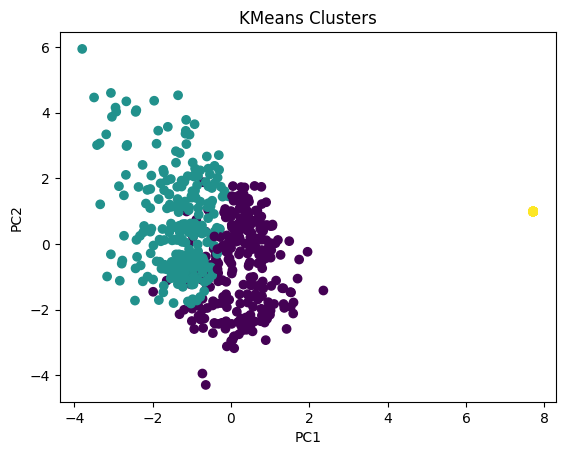

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters")
plt.show()

In [20]:
cluster_map = {
    0: "momentary",
    1: "none",
    2: "Hard"
}

In [29]:
new_data = [[5000, 5000, 12, 210, 4.0, 12.0, 2.8, 2.0, -2.5, 1.5, 20.0,300]]
new_scaled = scaler.transform(new_data)
cluster = kmeans.predict(new_scaled)
print(cluster)  

[0]


C:\Users\siddharth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


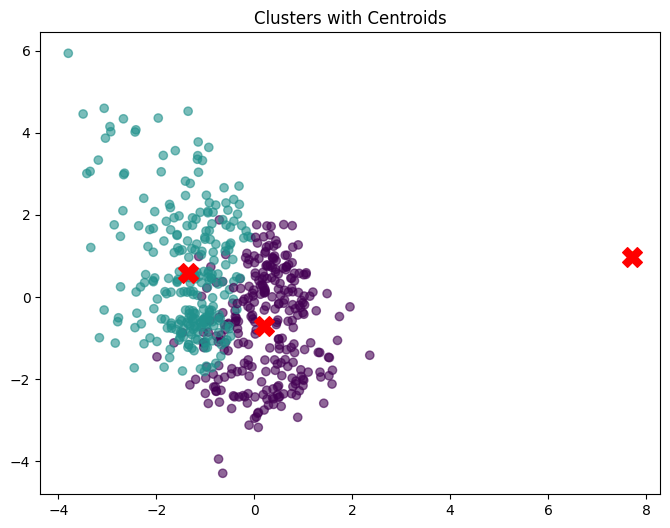

In [22]:
centers_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', s=200, marker='X')
plt.title("Clusters with Centroids")
plt.show()

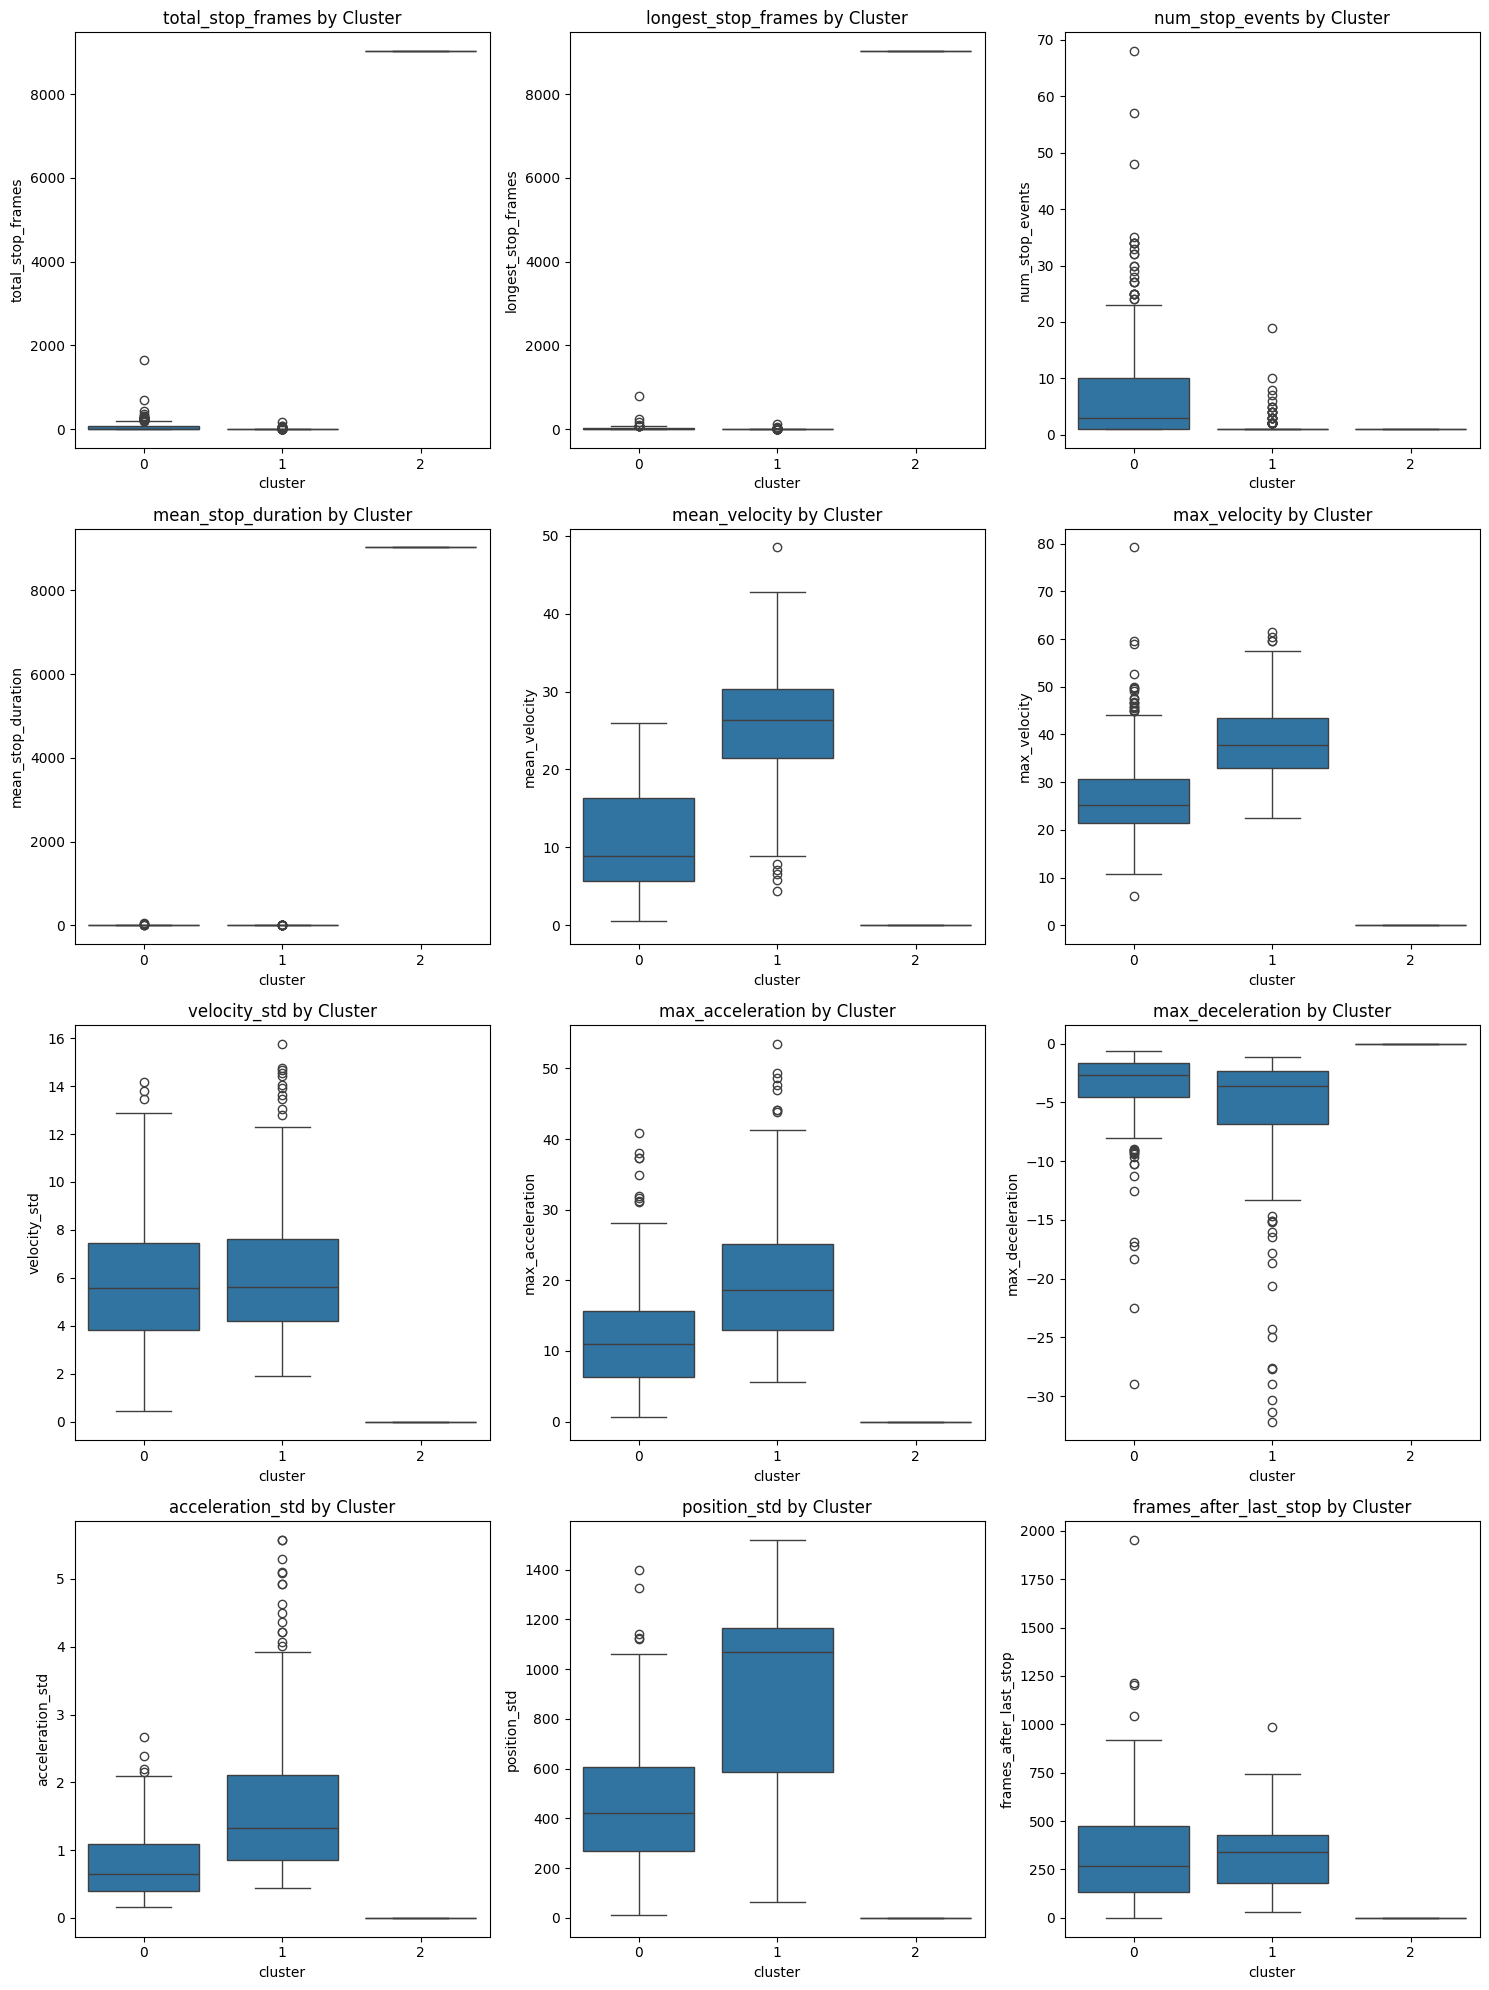

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n = len(features)
cols = 3  # number of plots per row
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

axes = axes.flatten()  # flatten in case of multiple rows

for i, feature in enumerate(features):
    sns.boxplot(x=df['cluster'], y=df[feature], ax=axes[i])
    axes[i].set_title(f"{feature} by Cluster")

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

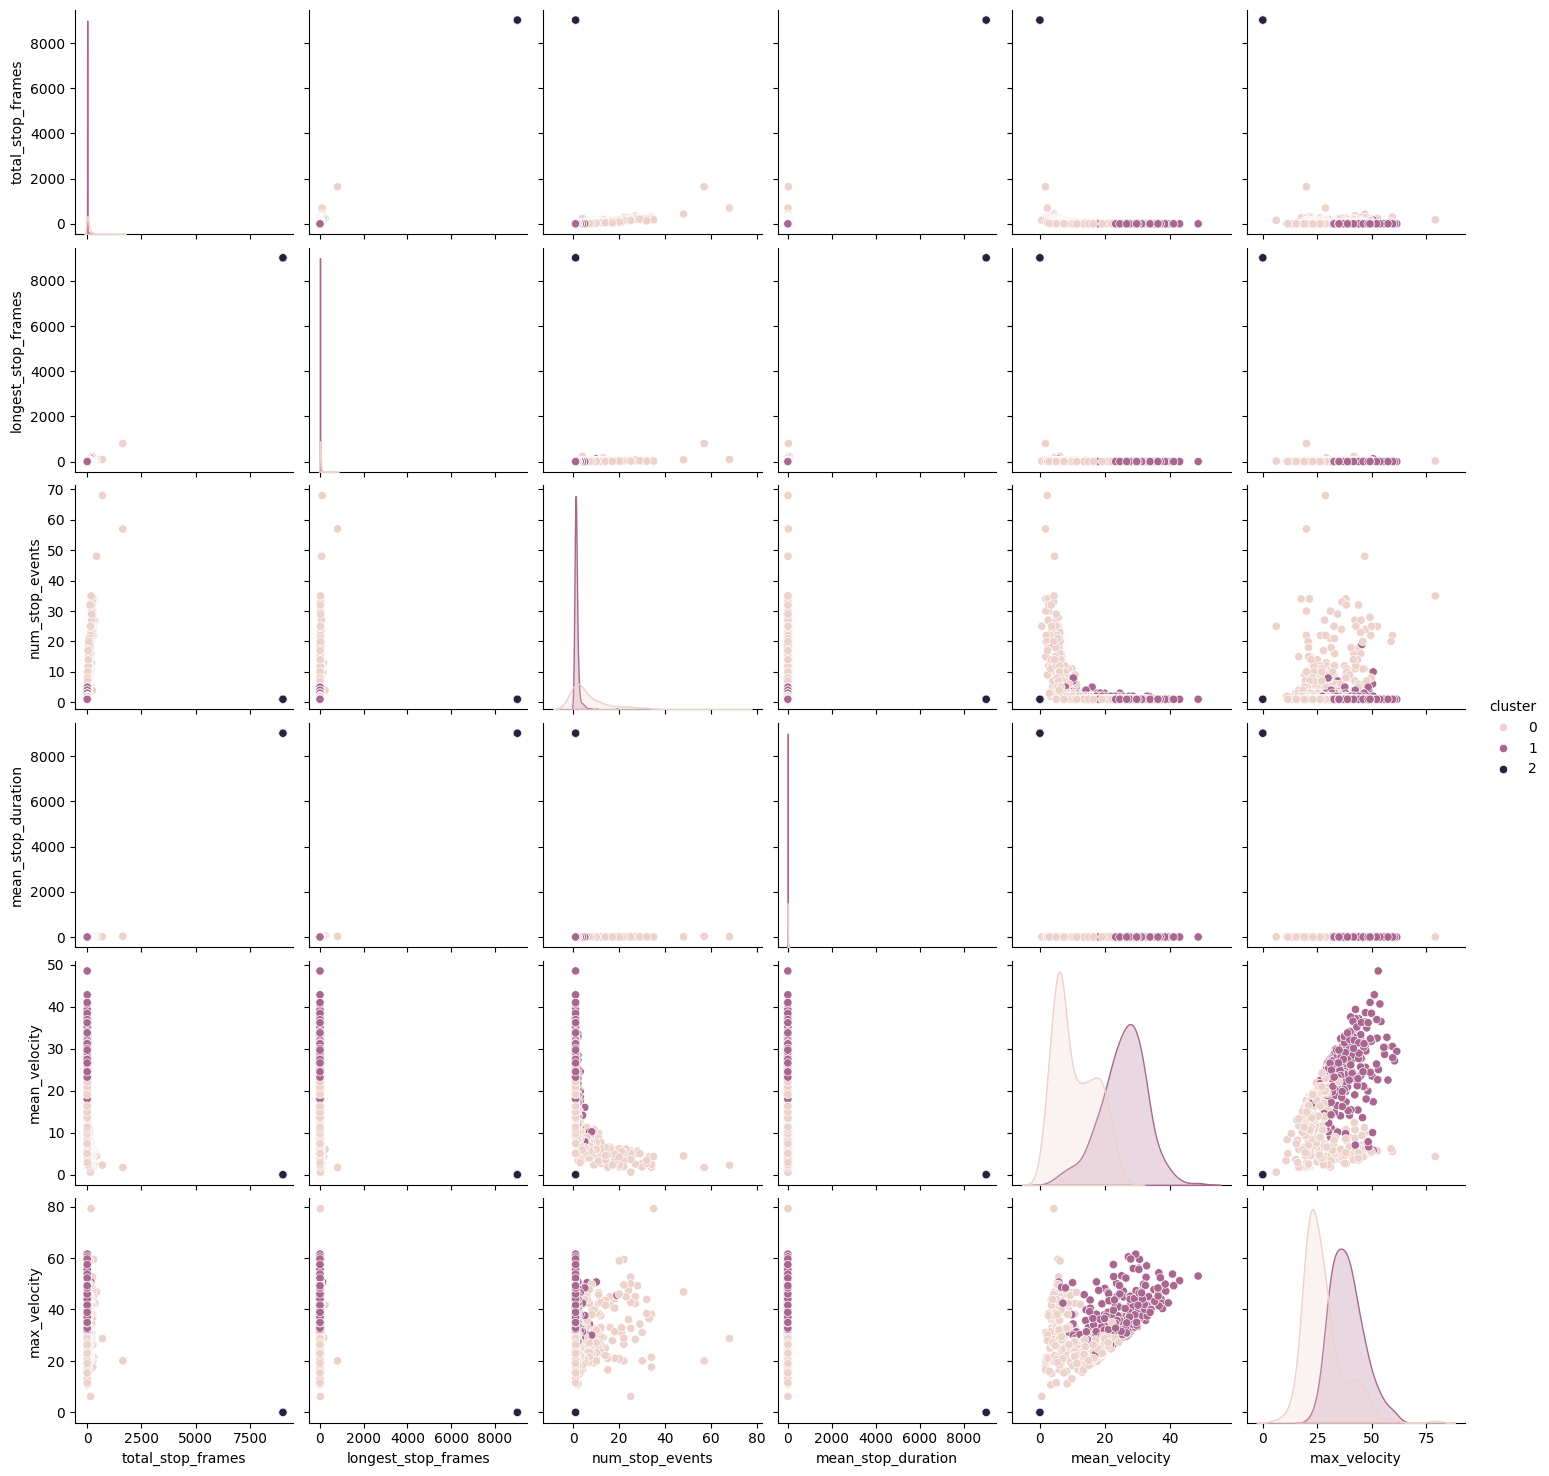

In [24]:
import seaborn as sns

sns.pairplot(df, vars=features[:6], hue='cluster')
plt.show()